In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.         -6.43402506  0.          0.          0.          0.
 -3.46300275  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          9.71065693
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          3.39035674  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -3.66072697  0.          0.
  0.          0.          0.          0.          6.79417452  0.
  0.         -3.0605458   0.          0.          0.          0.
  0.  

21.344585014099877

# Lasso Stochastic Bandit

# SA Lasso Bandit

In [6]:
from sklearn.linear_model import Lasso

def thresholded_lasso_bandit( T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)
        

        # Perform LASSO regression with lambda using Y_t and X_t
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti_lasso = lasso.coef_  # Estimated beta values
        

        # Define threshold
        threshold = 2 * lamada
    
        # Identify S_0: Indices where |beta| > threshold
        S_0 = np.where(np.abs(beta_esti_lasso) > threshold)[0]
        
        # Identify S_1: Indices where beta > threshold * |S_0| (length of S_0)
        # S_1_threshold = threshold * len(S_0)
        # S_1 = np.where(np.abs(beta_esti_lasso) > S_1_threshold)[0]
        
        # If S_1 is empty, randomly select one feature
        #if len(S_1) == 0:
            #S_1 = [np.random.choice(X_t.shape[1])]

        if len(S_0) == 0:
            S_0 = [np.random.choice(X_t.shape[1])]
    
        # Select features in X_t corresponding to S_1
        X_t_use = X_t[:, S_0]

        # Perform linear regression
        linear_model = LinearRegression(fit_intercept=False)
        linear_model.fit(X_t_use, Y_t)

        # Construct beta estimates
        beta_esti = np.zeros(X_t.shape[1])
        # beta_esti[S_1] = linear_model.coef_
        beta_esti[S_0] = linear_model.coef_

        #print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        #print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [7]:
def optimization_no_variance(beta_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [10]:
def while_thresholded_lasso_bandit(beta_star):
    L = 1
    error_std = 1
    C_max_wave = 1
    t = 2
    T = 1000 + 2
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = thresholded_lasso_bandit(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [12]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    print(times)
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_thresholded_lasso_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

0
1
2
3
4
5
6
7
8
9


In [13]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)


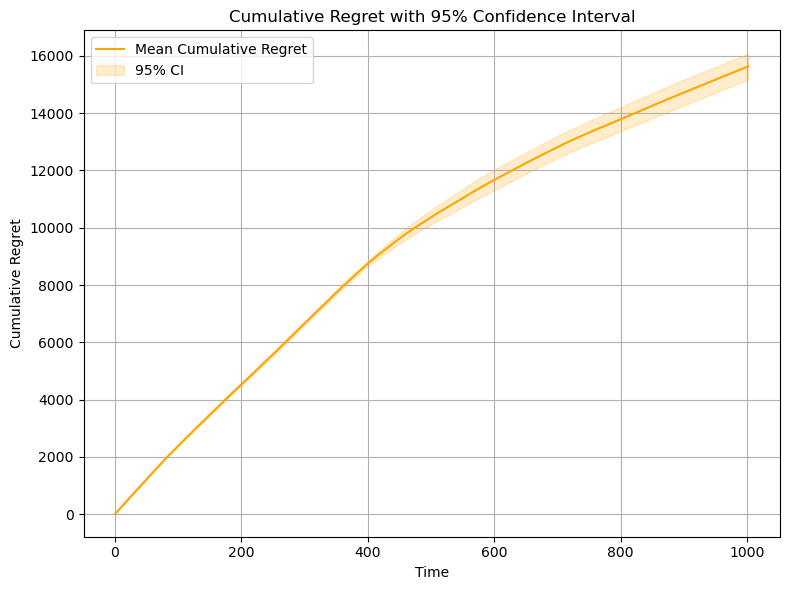

In [14]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [15]:
np.save('cumulative_regret_thresholded-lasso-bandit-d200-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_thresholded-lasso-bandit-d200-s10_10times.npy', l_2_error_parameter_times)